In [1]:
!pip install -U --no-index --find-links /kaggle/input/datasets/luciankucera/vllm-offline-wheels torch vllm datasets

Looking in links: /kaggle/input/datasets/luciankucera/vllm-offline-wheels
Processing /kaggle/input/datasets/luciankucera/vllm-offline-wheels/torch-2.10.0-3-cp312-cp312-manylinux_2_28_x86_64.whl
Processing /kaggle/input/datasets/luciankucera/vllm-offline-wheels/vllm-0.17.1-cp38-abi3-manylinux_2_31_x86_64.whl
Processing /kaggle/input/datasets/luciankucera/vllm-offline-wheels/datasets-4.8.2-py3-none-any.whl
Processing /kaggle/input/datasets/luciankucera/vllm-offline-wheels/cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (from torch)
Processing /kaggle/input/datasets/luciankucera/vllm-offline-wheels/nvidia_cuda_nvrtc_cu12-12.8.93-py3-none-manylinux2010_x86_64.manylinux_2_12_x86_64.whl (from torch)
Processing /kaggle/input/datasets/luciankucera/vllm-offline-wheels/nvidia_cuda_runtime_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (from torch)
Processing /kaggle/input/datasets/luciankucera/vllm-offline-wheels/nvidia_cuda_cupti_cu12-12.8.

In [2]:
import polars as pl
import os 
from vllm import LLM, SamplingParams
import torch
from datasets import Dataset
import re
torch.__version__

2026-03-18 14:20:27.887725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773843628.094662      66 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773843628.150206      66 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773843628.675285      66 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773843628.675299      66 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773843628.675300      66 computation_placer.cc:177] computation placer alr

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

'2.10.0+cu128'

In [3]:
class Config:
    model_dir = "/kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1"
    train_path = "/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/train.csv"
    test_path = "/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/test.csv"
    max_lora_rank = 32
    max_tokens = 7680
    top_p = 1.0
    temperature = 0.0
    max_num_seqs = 64
    gpu_memory_utilization = 0.85
    max_model_len = 8192

In [4]:
import polars as pl
import os 
from vllm import LLM, SamplingParams
import torch
from datasets import Dataset
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

In [5]:
sampling_params = SamplingParams(
    temperature=Config.temperature,
    top_p=Config.top_p,
    max_tokens=Config.max_tokens
)

In [6]:
llm = LLM(
    model=Config.model_dir,
    trust_remote_code=True,
    max_model_len=Config.max_model_len
)

INFO 03-18 14:20:41 [utils.py:238] non-default args: {'trust_remote_code': True, 'max_model_len': 8192, 'disable_log_stats': True, 'model': '/kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1'}


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


INFO 03-18 14:20:53 [model.py:531] Resolved architecture: NemotronHForCausalLM
INFO 03-18 14:20:53 [model.py:1554] Using max model len 8192
INFO 03-18 14:20:53 [scheduler.py:231] Chunked prefill is enabled with max_num_batched_tokens=16384.
INFO 03-18 14:20:53 [config.py:618] Updating mamba_ssm_cache_dtype to 'float32' for NemotronH model
INFO 03-18 14:20:53 [config.py:544] Setting attention block size to 2096 tokens to ensure that attention page size is >= mamba page size.
INFO 03-18 14:20:53 [config.py:575] Padding mamba page size by 0.58% to ensure that mamba page size and attention page size are exactly equal.
INFO 03-18 14:20:53 [vllm.py:747] Asynchronous scheduling is enabled.
WARNING 03-18 14:20:54 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized


2026-03-18 14:20:58.686966: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773843658.697166     414 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773843658.700198     414 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773843658.707690     414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773843658.707705     414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773843658.707706     414 computation_placer.cc:177] computation placer alr

(EngineCore_DP0 pid=414) INFO 03-18 14:21:02 [core.py:101] Initializing a V1 LLM engine (v0.17.1) with config: model='/kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1', speculative_config=None, tokenizer='/kaggle/input/models/metric/nemotron-3-nano-30b-a3b-bf16/transformers/default/1', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=8192, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityCon

...

(EngineCore_DP0 pid=414) INFO 03-18 14:28:04 [default_loader.py:293] Loading weights took 419.81 seconds
(EngineCore_DP0 pid=414) INFO 03-18 14:28:05 [gpu_model_runner.py:4364] Model loading took 58.91 GiB memory and 420.050557 seconds
(EngineCore_DP0 pid=414) INFO 03-18 14:28:07 [backends.py:916] Using cache directory: /root/.cache/vllm/torch_compile_cache/6aee2d7c5a/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=414) INFO 03-18 14:28:07 [backends.py:976] Dynamo bytecode transform time: 1.96 s
(EngineCore_DP0 pid=414) INFO 03-18 14:28:08 [backends.py:350] Cache the graph of compile range (1, 16384) for later use


(EngineCore_DP0 pid=414) /usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
(EngineCore_DP0 pid=414)   warnings.warn(


(EngineCore_DP0 pid=414) WARNING 03-18 14:28:11 [fused_moe.py:1093] Using default MoE config. Performance might be sub-optimal! Config file not found at /usr/local/lib/python3.12/dist-packages/vllm/model_executor/layers/fused_moe/configs/E=128,N=1856,device_name=NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition.json
(EngineCore_DP0 pid=414) INFO 03-18 14:28:15 [backends.py:366] Compiling a graph for compile range (1, 16384) takes 7.63 s
(EngineCore_DP0 pid=414) INFO 03-18 14:28:15 [monitor.py:35] torch.compile takes 9.99 s in total
(EngineCore_DP0 pid=414) INFO 03-18 14:28:15 [decorators.py:580] saving AOT compiled function to /root/.cache/vllm/torch_compile_cache/torch_aot_compile/bf7cccf3e39b3e78656c261f232a5c8094b6cb77a99bf493352b56cfc6c7c97a/rank_0_0/model
(EngineCore_DP0 pid=414) INFO 03-18 14:28:15 [decorators.py:588] saved AOT compiled function to /root/.cache/vllm/torch_compile_cache/torch_aot_compile/bf7cccf3e39b3e78656c261f232a5c8094b6cb77a99bf493352b56cfc6c7c97a/rank_0_0/model
(E

(EngineCore_DP0 pid=414) 2026-03-18 14:28:20,933 - INFO - autotuner.py:256 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
(EngineCore_DP0 pid=414) 2026-03-18 14:28:20,982 - INFO - autotuner.py:262 - flashinfer.jit: [Autotuner]: Autotuning process ends
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:04<00:00, 11.35it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 51/51 [00:42<00:00,  1.21it/s]


(EngineCore_DP0 pid=414) INFO 03-18 14:29:08 [gpu_model_runner.py:5386] Graph capturing finished in 48 secs, took -0.90 GiB
(EngineCore_DP0 pid=414) INFO 03-18 14:29:08 [core.py:282] init engine (profile, create kv cache, warmup model) took 63.47 seconds
(EngineCore_DP0 pid=414) INFO 03-18 14:29:09 [vllm.py:747] Asynchronous scheduling is enabled.
INFO 03-18 14:29:09 [llm.py:388] Supported tasks: ['generate']


## usefull functions

In [7]:
def extract_final_answer(text: str | None) -> str:
    r"""Extracts the final answer from the model response.

    Prioritizes extracting answers inside `\boxed{}`.
    If no `\boxed{}` format is found, attempts to extract numbers from other formats.

    Examples:
        >>> extract_final_answer(r"The answer is \boxed{42}")
        '42'
        >>> extract_final_answer("The final answer is: 3.14")
        '3.14'
        >>> extract_final_answer("Just a number 100 in text")
        '100'
        >>> extract_final_answer(None)
        'NOT_FOUND'
    """
    if text is None:
        return 'NOT_FOUND'

    # Search for boxed answer
    # Match all instances of \boxed{...} or unclosed \boxed{ at the end
    matches = re.findall(r'\\boxed\{([^}]*)(?:\}|$)', text)
    if matches:
        non_empty = [m.strip() for m in matches if m.strip()]
        if non_empty:
            return non_empty[-1]
        return matches[-1].strip()

    # Other common formats if \boxed{} is not found
    patterns = [
        r'The final answer is:\s*([^\n]+)',
        r'Final answer is:\s*([^\n]+)',
        r'Final answer\s*[:：]\s*([^\n]+)',
        r'final answer\s*[:：]\s*([^\n]+)',
    ]
    for pattern in patterns:
        matches = re.findall(pattern, text, re.IGNORECASE)
        if matches:
            return matches[-1].strip()

    # If no structured format is found, extract the last valid number in the text
    matches = re.findall(r'-?\d+(?:\.\d+)?', text)
    if matches:
        return matches[-1]

    # If no numeric answer is found, return the last line of text as a fallback
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    return lines[-1] if lines else 'NOT_FOUND'

In [8]:
def add_predictions(model,prompts,data):
    outputs = llm.generate(prompts,sampling_params)
    predictions = []
    raw_text_preds = []
    for output in outputs:
        raw_text = output.outputs[0].text
        extracted_answer = extract_final_answer(raw_text)
        predictions.append(extracted_answer)
        raw_text_preds.append(raw_text)
    return data.with_columns(pl.Series("predictions",predictions),pl.Series("raw_text",raw_text_preds))

## Inference and Analysis of model preds

In [9]:
train_data = pl.read_csv(Config.train_path).with_columns(question=pl.col("prompt").str.split("\n").list[0])
correct_question_dict = { q:0 for q in train_data.group_by(pl.col("question")).len()["question"].to_list() }
incorrect_question_dict = { q:0 for q in train_data.group_by(pl.col("question")).len()["question"].to_list() }
train_data.head()

id,prompt,answer,question
str,str,str,str
"""00066667""","""In Alice's Wonderland, a secre…","""10010111""","""In Alice's Wonderland, a secre…"
"""000b53cf""","""In Alice's Wonderland, a secre…","""01000011""","""In Alice's Wonderland, a secre…"
"""00189f6a""","""In Alice's Wonderland, secret …","""cat imagines book""","""In Alice's Wonderland, secret …"
"""001b24c4""","""In Alice's Wonderland, numbers…","""XXXVIII""","""In Alice's Wonderland, numbers…"
"""001c63cb""","""In Alice's Wonderland, secret …","""wizard creates secret""","""In Alice's Wonderland, secret …"


In [10]:
def prepare_dataset(model,data):
    tokenizer = llm.get_tokenizer()
    prompts = []
    for item in data.iter_rows(named=True):
        user_content = (
                item["prompt"]
                + '\nPlease put your final answer inside `\\boxed{}`. For example: `\\boxed{your answer}`'
        )
            # Format using the tokenizer's chat template directly
        try:
            prompt = tokenizer.apply_chat_template(
                    [{'role': 'user', 'content': user_content}],
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=True,
                )
        except Exception:
            prompt = user_content
        prompts.append(prompt)
    return prompts

In [11]:
prompts = prepare_dataset(llm,train_data)

In [12]:
data_with_preds = add_predictions(llm,prompts,train_data)

Rendering prompts:   0%|          | 0/9500 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/9500 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…

In [13]:
data_with_preds = data_with_preds.with_columns(correct = pl.col("answer") == pl.col("predictions"))
data_with_preds

id,prompt,answer,question,predictions,raw_text,correct
str,str,str,str,str,str,bool
"""00066667""","""In Alice's Wonderland, a secre…","""10010111""","""In Alice's Wonderland, a secre…","""5""","""We need to infer transformatio…",false
"""000b53cf""","""In Alice's Wonderland, a secre…","""01000011""","""In Alice's Wonderland, a secre…","""0011011""","""We need to infer transformatio…",false
"""00189f6a""","""In Alice's Wonderland, secret …","""cat imagines book""","""In Alice's Wonderland, secret …","""cat imagines book""","""We need to figure out encrypti…",true
"""001b24c4""","""In Alice's Wonderland, numbers…","""XXXVIII""","""In Alice's Wonderland, numbers…","""XXXVIII""","""We need to infer the numeral s…",true
"""001c63cb""","""In Alice's Wonderland, secret …","""wizard creates secret""","""In Alice's Wonderland, secret …","""wizard creates secret""","""We need to figure out mapping …",true
…,…,…,…,…,…,…
"""ffce9e31""","""In Alice's Wonderland, a secre…","""01100110""","""In Alice's Wonderland, a secre…","""1""","""We need to infer transformatio…",false
"""ffd5bada""","""In Alice's Wonderland, a secre…","""32.45""","""In Alice's Wonderland, a secre…","""1.286""","""We need to find the conversion…",false
"""ffd89354""","""In Alice's Wonderland, secret …","""student sees the curious mirro…","""In Alice's Wonderland, secret …","""student sees the curious mirro…","""We need to figure out encrypti…",true


In [14]:
correct_count =  data_with_preds.filter(pl.col("correct")).group_by(pl.col("question")).len()
incorrect_count =  data_with_preds.filter(~pl.col("correct")).group_by(pl.col("question")).len()

In [15]:
for row in correct_count.iter_rows(named="true"):
    correct_question_dict[row["question"]]+=row["len"]
for row in incorrect_count.iter_rows(named="true"):
    incorrect_question_dict[row["question"]]+=row["len"]

In [16]:
correct_question_tuples =  sorted([(k,v) for k,v  in correct_question_dict.items()],key=lambda x:x[0])
correct_question_tuples

[("In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.",
  131),
 ("In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:",
  180),
 ("In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:",
  705),
 ("In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:",
  1574),
 ("In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:",
  644),
 ("In Alice's Wonderland, the gravitational constant has been secretly changed. Here are some example observations:",
  581)]

In [17]:
incorrect_question_tuples =  sorted([(k,v) for k,v  in incorrect_question_dict.items()],key=lambda x:x[0])
incorrect_question_tuples

[("In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.",
  1471),
 ("In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:",
  1375),
 ("In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:",
  889),
 ("In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:",
  2),
 ("In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:",
  932),
 ("In Alice's Wonderland, the gravitational constant has been secretly changed. Here are some example observations:",
  1016)]

In [18]:
data_with_preds.write_csv("/kaggle/working/preds.csv")

## Analyzing output

In [19]:
relabel = {
    "In Alice's Wonderland, a secret bit manipulation rule transforms 8-bit binary numbers. The transformation involves operations like bit shifts, rotations, XOR, AND, OR, NOT, and possibly majority or choice functions.":"bit",
    "In Alice's Wonderland, a secret set of transformation rules is applied to equations. Below are a few examples:":"equation",
    "In Alice's Wonderland, a secret unit conversion is applied to measurements. For example:":"mesurement conversion",
    "In Alice's Wonderland, numbers are secretly converted into a different numeral system. Some examples are given below:":"number conversion",
    "In Alice's Wonderland, secret encryption rules are used on text. Here are some examples:":"encryption",
    "In Alice's Wonderland, the gravitational constant has been secretly changed. Here are some example observations:":"gravitational"
}

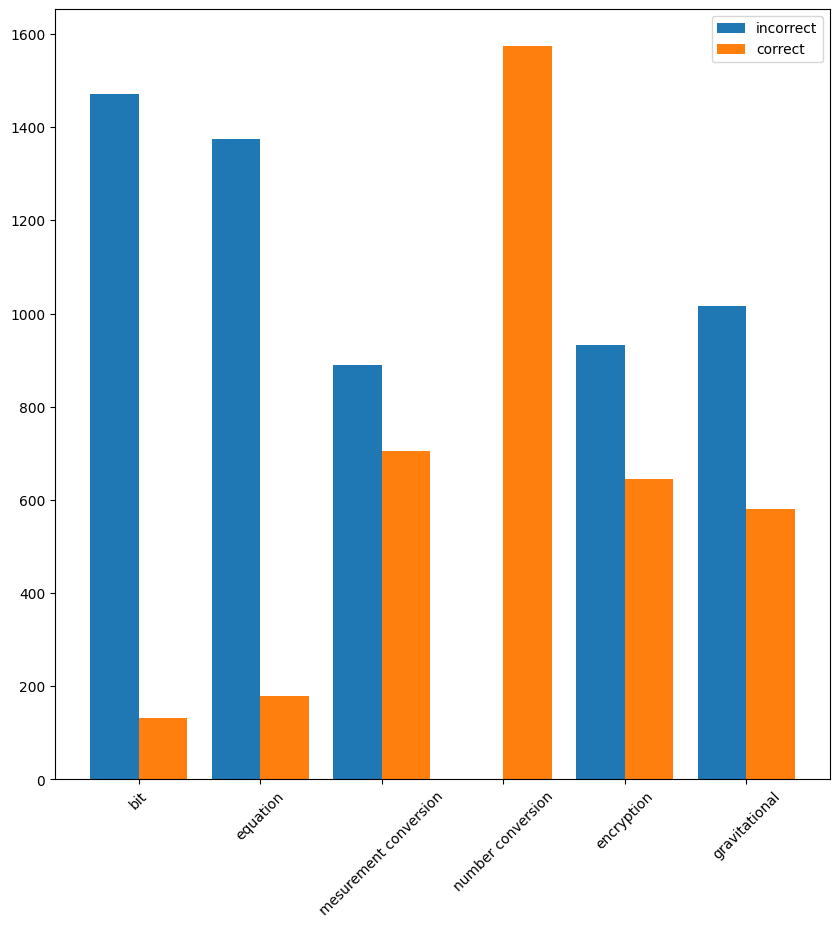

In [20]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot()
ax.bar(np.array(range(len(incorrect_question_dict)))-0.2,[v[1] for v in incorrect_question_tuples],width=0.4,label="incorrect")
ax.bar(np.array(range(len(correct_question_dict)))+0.2,[v[1] for v in correct_question_tuples],width=0.4,label="correct")
ax.xaxis.set_ticks(np.array(range(len(incorrect_question_dict))))
ax.set_xticklabels([relabel[v[0]] for v in correct_question_tuples], rotation=45)
ax.legend()